# 📊 Visualizaciones Mejoradas de Clusters

**Objetivo**: Crear visualizaciones avanzadas para interpretación de clusters

**Incluye**:
- t-SNE/UMAP 2D y 3D
- Distribuciones por cluster
- Matriz de transición (si aplica)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.manifold import TSNE
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Cargar Datos con Clusters

In [2]:
# Cargar datos con clusters asignados
df_clusters = pd.read_csv('../data/customer_clusters.csv')

# Cargar datos originales
df_raw = pd.read_csv('../../clustering/data/df_for_clustering.csv')
df_raw.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_raw = df_raw[df_raw['deceased'] == 'N']

# Merge
df = df_raw.merge(df_clusters, on='pk_cid')

print(f"Datos cargados: {df.shape}")
print(f"Distribución clusters:\n{df['cluster'].value_counts().sort_index()}")

Datos cargados: (442909, 25)
Distribución clusters:
cluster
1    113727
2     65422
3     82927
4     49068
5     86414
6     45351
Name: count, dtype: int64


## 2. Preparar Features para Visualización

In [3]:
# Mismo preprocesamiento
df_viz = df.copy()
df_viz.drop(columns=['deceased', 'gender', 'entry_channel'], inplace=True, errors='ignore')
df_viz.drop(columns=['z_pct_months_active', 'account', 'z_num_families'], inplace=True, errors='ignore')
df_viz.drop(columns=['macro_region', 'is_coast'], inplace=True, errors='ignore')
df_viz.drop(columns=['pk_cid', 'pk_partition', 'cluster', 'cluster_name'], inplace=True, errors='ignore')

# OHE
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df_viz[['segment', 'city_size']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['segment', 'city_size']), index=df_viz.index)
df_viz = df_viz.drop(columns=['segment', 'city_size'])
df_viz = pd.concat([df_viz, encoded_df], axis=1)

# Normalizar
scaler = MinMaxScaler()
df_viz[['age', 'salary', 'z_months_since_entry', 'z_num_products']] = scaler.fit_transform(
    df_viz[['age', 'salary', 'z_months_since_entry', 'z_num_products']]
)

print(f"Features preparadas: {df_viz.shape}")

Features preparadas: (442909, 18)


## 3. t-SNE 2D

In [4]:
print("Calculando t-SNE 2D (puede tardar 2-3 minutos)...")

# Usar muestra si hay muchos datos
sample_size = min(10000, len(df_viz))
indices = np.random.choice(len(df_viz), sample_size, replace=False)

X_sample = df_viz.iloc[indices]
clusters_sample = df['cluster'].iloc[indices]
names_sample = df['cluster_name'].iloc[indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

print("✅ t-SNE completado")

Calculando t-SNE 2D (puede tardar 2-3 minutos)...


/Users/alex/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ t-SNE completado


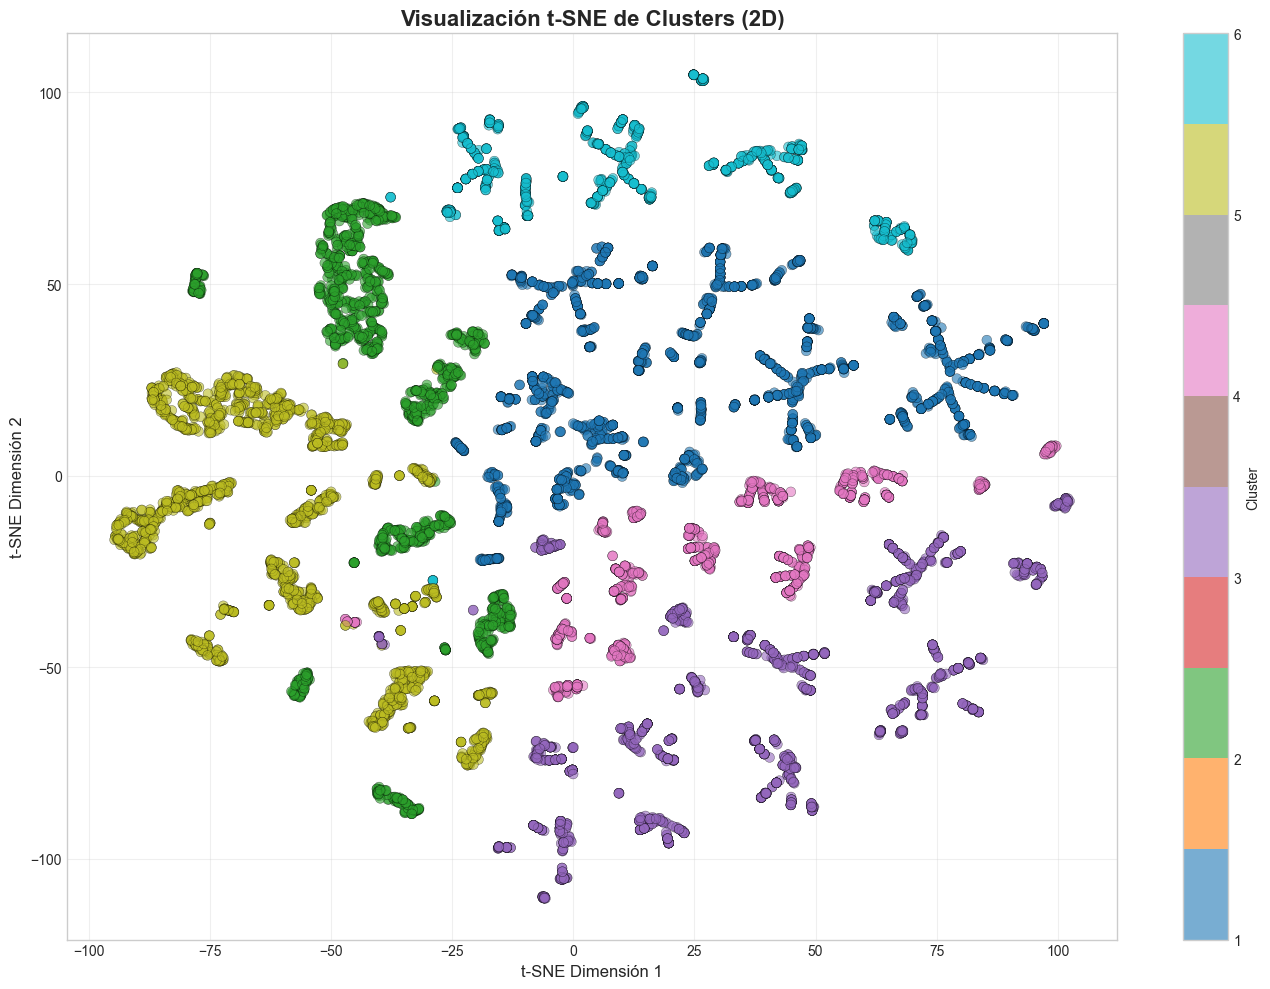

In [5]:
# Visualizar
plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters_sample,
    cmap='tab10',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.3
)

plt.colorbar(scatter, label='Cluster', ticks=range(1, 7))
plt.title('Visualización t-SNE de Clusters (2D)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimensión 1', fontsize=12)
plt.ylabel('t-SNE Dimensión 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/tsne_2d.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Distribuciones de Variables Clave

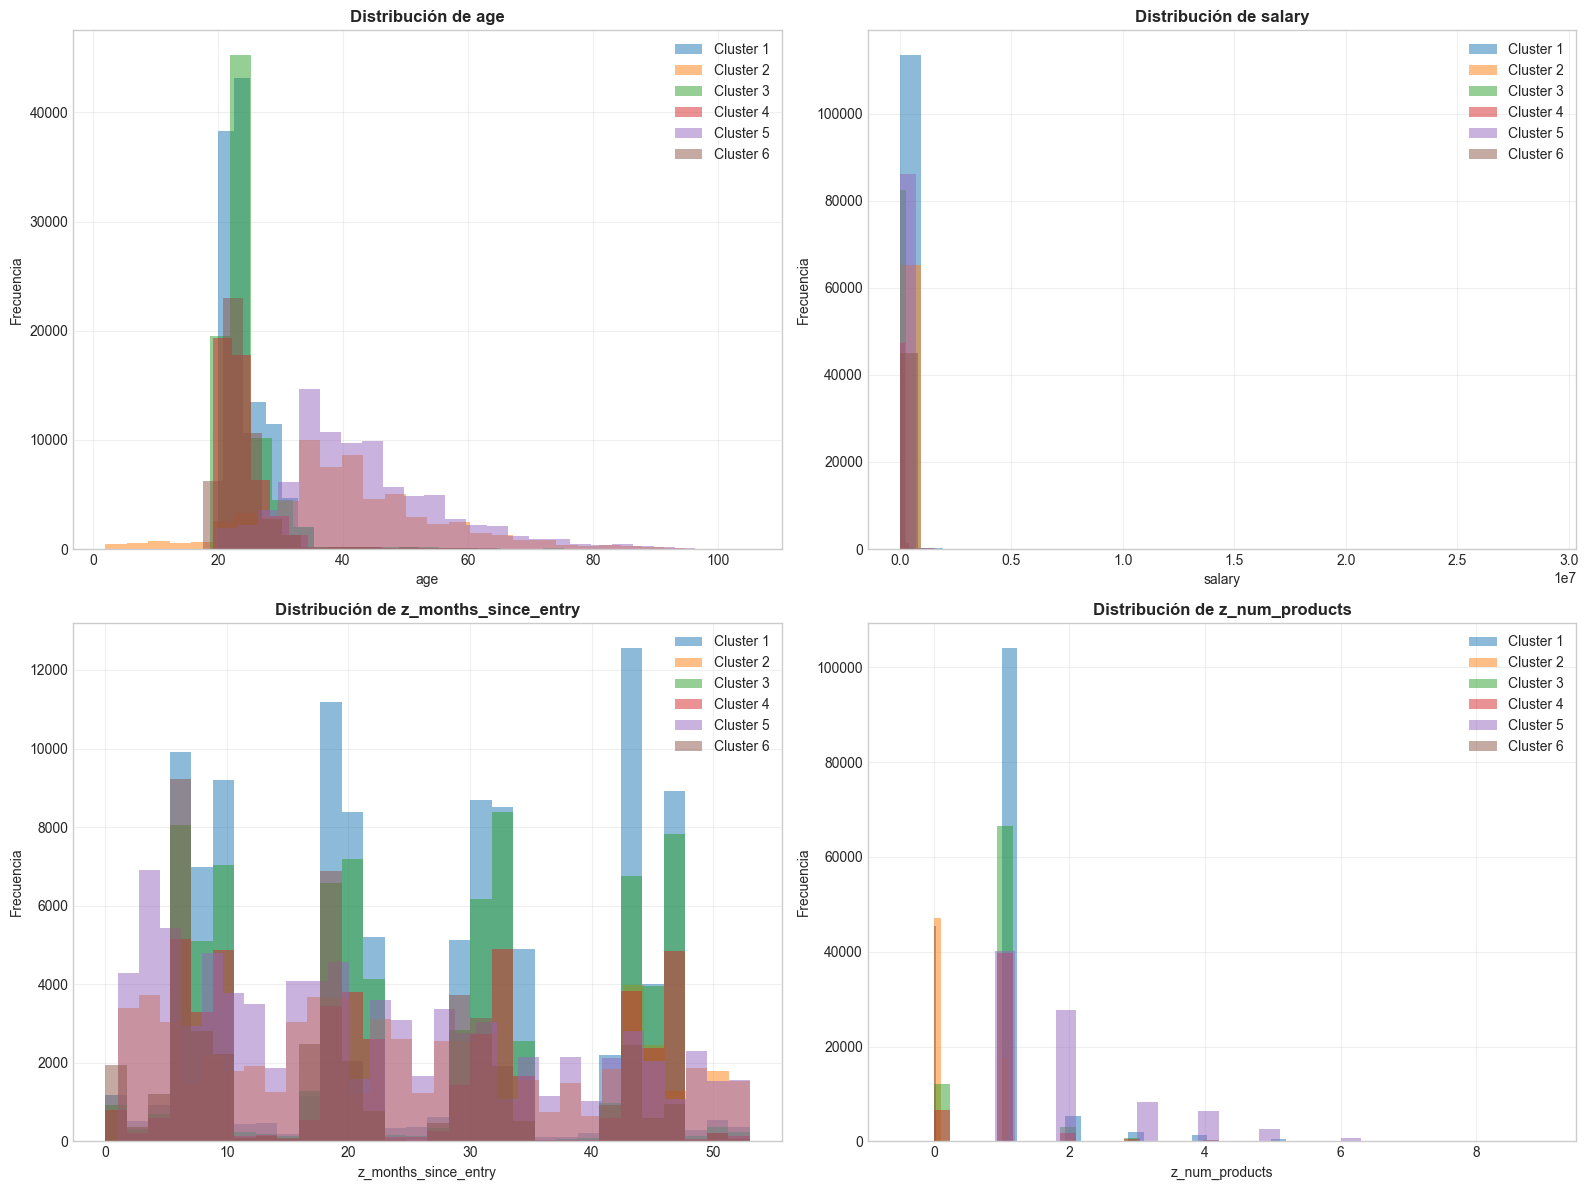

In [6]:
# Variables a visualizar
vars_to_plot = ['age', 'salary', 'z_months_since_entry', 'z_num_products']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, var in enumerate(vars_to_plot):
    for cluster_id in sorted(df['cluster'].unique()):
        cluster_data = df[df['cluster'] == cluster_id][var]
        axes[i].hist(cluster_data, alpha=0.5, label=f'Cluster {cluster_id}', bins=30)
    
    axes[i].set_title(f'Distribución de {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/distributions_by_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Radar Chart por Cluster

In [7]:
# Preparar datos normalizados para radar
radar_vars = ['age', 'salary', 'z_months_since_entry', 'z_num_products', 'active_customer']

cluster_means = df.groupby('cluster')[radar_vars].mean()

# Normalizar a 0-1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

print("\n📊 PERFILES NORMALIZADOS\n")
display(cluster_means_norm.round(2))


📊 PERFILES NORMALIZADOS



,age,salary,z_months_since_entry,z_num_products,active_customer
cluster,,,,,
1,0.02,0.60,1.00,0.60,0.30
2,0.88,0.31,0.79,0.15,0.05
3,0.01,0.00,0.95,0.48,0.35
4,0.02,0.11,0.85,0.49,0.32
5,1.00,0.45,0.32,1.00,1.00
6,0.00,1.00,0.00,0.00,0.00


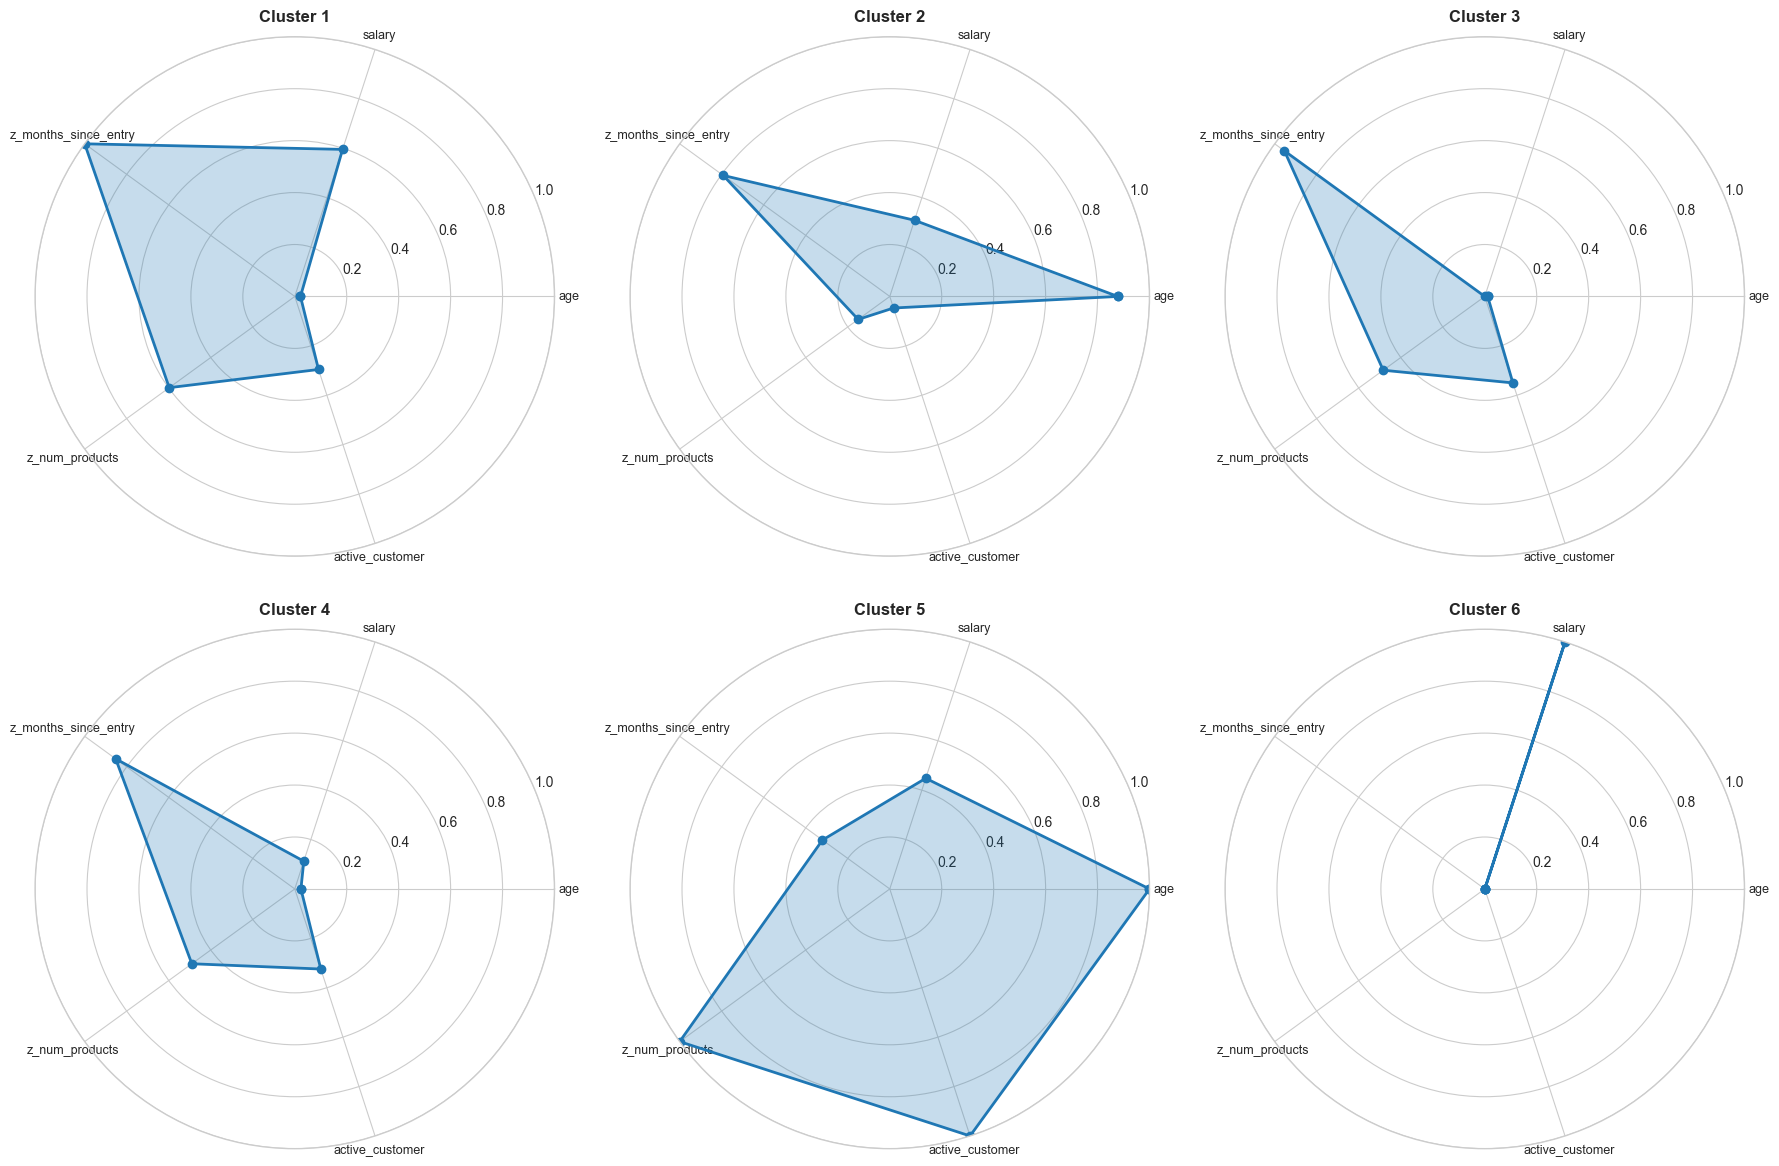

In [8]:
# Radar chart para cada cluster
from math import pi

categories = radar_vars
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(projection='polar'))
axes = axes.ravel()

for idx, cluster_id in enumerate(sorted(df['cluster'].unique())):
    ax = axes[idx]
    
    values = cluster_means_norm.loc[cluster_id].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}', fontweight='bold', size=12)
    ax.grid(True)

plt.tight_layout()
plt.savefig('../visualizations/radar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Resumen Visual de Tamaños

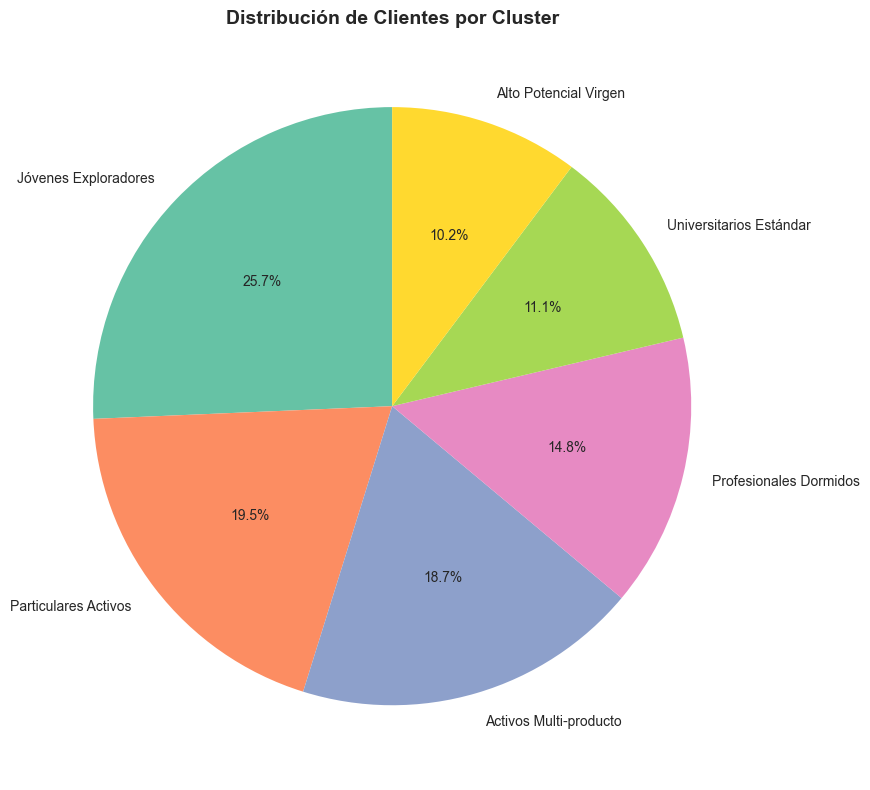

In [9]:
# Pie chart de distribución
cluster_sizes = df['cluster_name'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(
    cluster_sizes.values,
    labels=cluster_sizes.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(cluster_sizes))
)
plt.title('Distribución de Clientes por Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

---

## ✅ Visualizaciones creadas:
1. t-SNE 2D
2. Distribuciones por variable
3. Radar charts por cluster
4. Pie chart de distribución

### Próximo paso:
→ Notebook `04_propensity_integration.ipynb`
